# Backpropagation, From Scratch\n\nBackprop is the chain rule, applied layer by layer, to turn \"the output was wrong\" into \"here's how much to nudge every single weight.\" No `torch.autograd`, no `tf.GradientTape` — every gradient here is derived by hand and coded directly in numpy.\n\nThe task: teach a tiny network **XOR**. XOR is the classic example because it's *not linearly separable* — no single straight line divides the two classes, so a network with no hidden layer (logistic regression, essentially) provably cannot learn it. A hidden layer can, by bending the input space until a straight line works.\n\nThe companion interactive version — same math, live in the browser, with a probeable network diagram — lives at `web/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "axes.edgecolor": "#383835",
    "axes.labelcolor": "#ffffff",
    "text.color": "#ffffff",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "grid.color": "#2c2c2a",
    "axes.grid": True,
    "grid.linewidth": 0.5,
    "font.size": 11,
})

rng = np.random.default_rng(42)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)  # XOR

HIDDEN_SIZE = 3

## The network and the forward pass

A 2-input, 3-hidden-neuron, 1-output network, fully connected, sigmoid activation everywhere:

$$h = \sigma(X W_1 + b_1) \qquad \hat{y} = \sigma(h W_2 + b_2) \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

$X$ is a batch of inputs (rows = examples), so $W_1$ is a $2\times3$ matrix, $W_2$ is $3\times1$ — the whole batch runs through in one matrix multiply.

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def init_params(hidden_size=HIDDEN_SIZE, seed=42):
    rng = np.random.default_rng(seed)
    return {
        "W1": rng.uniform(-1, 1, size=(2, hidden_size)),
        "b1": rng.uniform(-1, 1, size=(hidden_size,)),
        "W2": rng.uniform(-1, 1, size=(hidden_size, 1)),
        "b2": rng.uniform(-1, 1, size=(1,)),
    }


def forward(params, X):
    h = sigmoid(X @ params["W1"] + params["b1"])
    y_hat = sigmoid(h @ params["W2"] + params["b2"])
    return h, y_hat


params = init_params()
h, y_hat = forward(params, X)
print("hidden activations:\n", h)
print("\npredictions (untrained):\n", y_hat)

hidden activations:
 [[0.62768061 0.6392542  0.3221797 ]
 [0.7144336  0.44040546 0.55168274]
 [0.74463333 0.61061201 0.49335617]
 [0.81228518 0.41053363 0.71599225]]

predictions (untrained):
 [[0.58303645]
 [0.63966572]
 [0.61707499]
 [0.6708796 ]]


## The backward pass — the chain rule, one layer at a time

Loss is mean squared error: $L = \frac{1}{n}\sum (\hat{y} - y)^2$. We need $\partial L / \partial W_1$, $\partial L / \partial b_1$, $\partial L / \partial W_2$, $\partial L / \partial b_2$ — how much each weight is responsible for the error.

Work backward from the output:

$$\frac{\partial L}{\partial \hat{y}} = 2(\hat{y} - y) \qquad \frac{\partial \hat{y}}{\partial z_2} = \hat{y}(1-\hat{y}) \qquad \delta_2 = \frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2}$$

That $\delta_2$ ("how wrong was the pre-activation output") gives us the output-layer gradients directly:

$$\frac{\partial L}{\partial W_2} = h^T \delta_2 \qquad \frac{\partial L}{\partial b_2} = \sum \delta_2$$

Then **the key backprop step**: push the error signal back through $W_2$ to find out how much each *hidden* neuron contributed, and multiply by that neuron's own local derivative:

$$\delta_1 = (\delta_2 W_2^T) \odot h(1-h) \qquad \frac{\partial L}{\partial W_1} = X^T \delta_1 \qquad \frac{\partial L}{\partial b_1} = \sum \delta_1$$

Every layer follows the same recipe: take the error signal from the layer in front of you, multiply by that layer's weights transposed, multiply by your own local derivative. That's the whole algorithm — it's called "back"-prop because this process runs from the output layer back to the input.

In [3]:
def mse_loss(y_hat, y):
    return float(np.mean((y_hat - y) ** 2))


def backward(params, X, y, h, y_hat):
    n = X.shape[0]

    d_loss_d_yhat = 2 * (y_hat - y) / n
    delta2 = d_loss_d_yhat * (y_hat * (1 - y_hat))          # (n, 1)

    dW2 = h.T @ delta2                                       # (hidden, 1)
    db2 = np.sum(delta2, axis=0)                              # (1,)

    delta1 = (delta2 @ params["W2"].T) * (h * (1 - h))       # (n, hidden)
    dW1 = X.T @ delta1                                        # (2, hidden)
    db1 = np.sum(delta1, axis=0)                              # (hidden,)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


def train_step(params, X, y, lr):
    h, y_hat = forward(params, X)
    grads = backward(params, X, y, h, y_hat)
    return {key: params[key] - lr * grads[key] for key in params}, mse_loss(y_hat, y)

## Training on XOR

Full-batch gradient descent: every step uses all four XOR examples. We snapshot the weights periodically so we can watch the decision boundary fold itself around the data.

In [4]:
TOTAL_EPOCHS = 3000
LR = 4.0
SNAPSHOT_EVERY = 500

params = init_params()
snapshots = [(0, params)]
losses = []

for epoch in range(1, TOTAL_EPOCHS + 1):
    params, loss = train_step(params, X, y, LR)
    losses.append(loss)
    if epoch % SNAPSHOT_EVERY == 0:
        snapshots.append((epoch, params))

print("final loss:", losses[-1])
print("final predictions:\n", forward(params, X)[1])

final loss: 0.00021931100030118865
final predictions:
 [[0.01513924]
 [0.98854266]
 [0.98305236]
 [0.01513999]]


## Watching the boundary fold

Each panel is the same network at a different point in training. Background color is the predicted probability of class 1; markers are the four XOR points (dark ring = class 0, light fill = class 1).

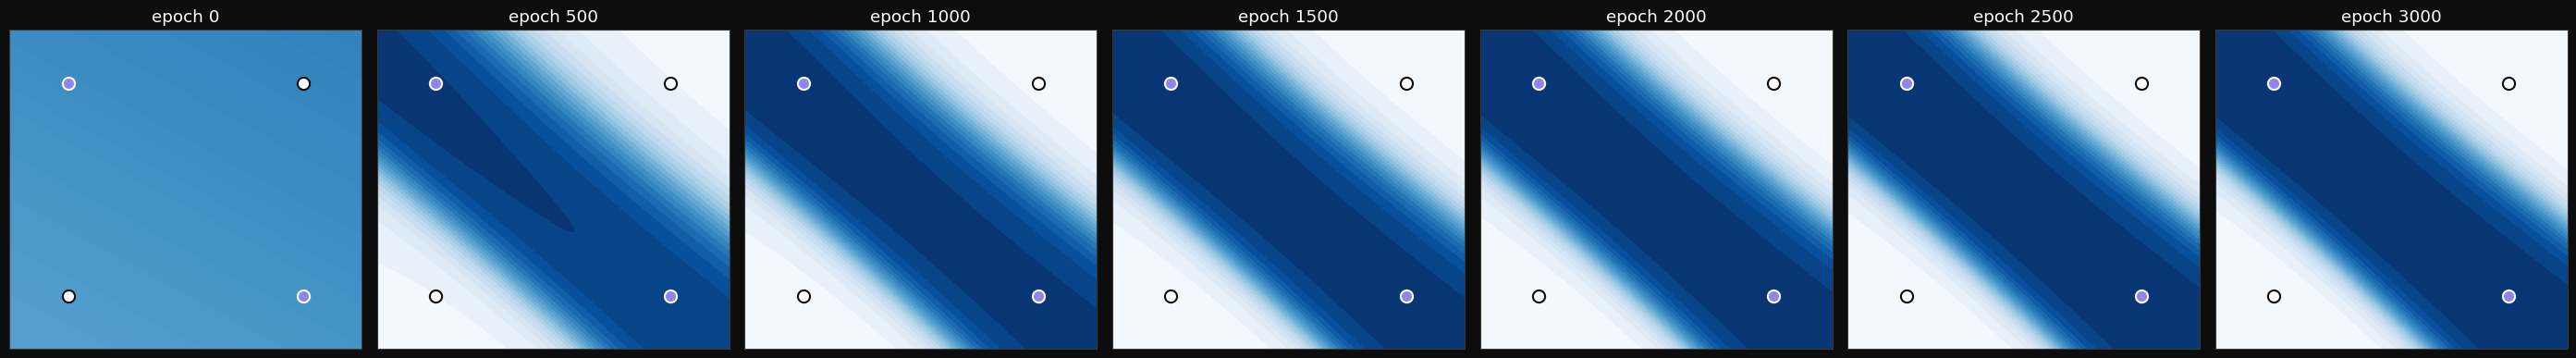

In [5]:
grid_n = 150
gx = np.linspace(-0.25, 1.25, grid_n)
gy = np.linspace(-0.25, 1.25, grid_n)
GX, GY = np.meshgrid(gx, gy)
grid_points = np.stack([GX.ravel(), GY.ravel()], axis=1)

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4))
for ax, (epoch, snap_params) in zip(axes, snapshots):
    _, preds = forward(snap_params, grid_points)
    Z = preds.reshape(grid_n, grid_n)
    ax.contourf(GX, GY, Z, levels=20, cmap="Blues", vmin=0, vmax=1)
    for xi, yi in zip(X, y):
        ax.scatter(
            *xi,
            s=90,
            facecolor="#9085e9" if yi[0] == 1 else "#ffffff",
            edgecolor="#ffffff" if yi[0] == 1 else "#0d0d0d",
            linewidth=1.5,
            zorder=3,
        )
    ax.set_title(f"epoch {epoch}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

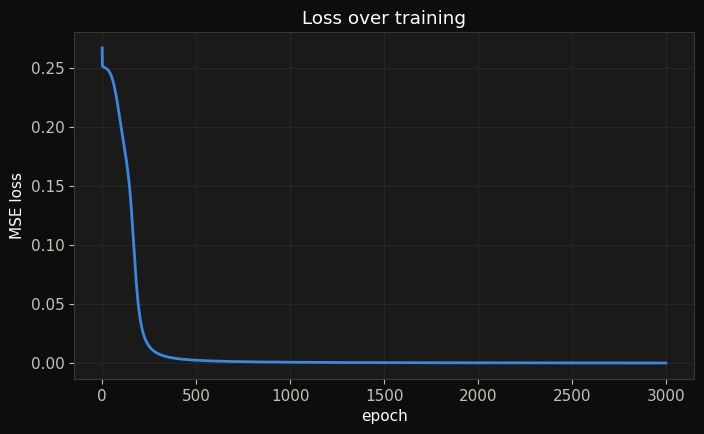

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(losses, color="#3987e5", linewidth=2)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Loss over training")
plt.show()

## Takeaways

- Backprop is the chain rule applied mechanically, layer by layer, back from the loss to every weight.
- Each layer's job during the backward pass is identical: take the error signal handed to you from the layer downstream, multiply by your own local derivative, and hand the result further upstream.
- A network with a hidden layer can learn XOR precisely because the hidden layer's nonlinearity lets it bend the decision boundary into something more than a straight line.
- "Training" is nothing more than: forward pass → compute loss → backward pass → nudge every weight against its gradient → repeat.